# Full DOS convergence analysis

## Objective

Apply the validated DOS-similarity workflow to every material currently returned by the DOI-specific NOMAD query for the FHI-aims numerical-quality dataset.

For each material, this notebook will:

1. retrieve the available DOS calculations from NOMAD using rate-limited requests;
2. automatically retry failed downloads;
3. generate DOS fingerprints;
4. calculate the pairwise DOS-similarity matrix;
5. save one heatmap;
6. record calculation counts, failures and runtimes.

The associated paper reports 144 materials. However, the current DOI-specific query returns 161 distinct reduced chemical formulas. This run therefore processes all 161 currently available materials.

Progress will be saved after every material, allowing an interrupted run to resume without repeating completed materials.

## 1. Import the required tools

This section loads the tools needed for data retrieval, DOS processing, similarity analysis, plotting, timing and saving progress.

**In short:** prepare the Python environment without downloading any data.

In [1]:
# Work safely with folder and file paths.
from pathlib import Path

# Measure the runtime of each processing stage.
from time import perf_counter

# Store the results from every material in CSV tables.
import pandas as pd

# Perform numerical operations, including sorting the similarity matrix.
import numpy as np

# Create and close figures.
import matplotlib.pyplot as plt

# Create and manage the local material databases.
from madas import MaterialsDatabase

# Connect MADAS to NOMAD using the same interface as the validated workflow.
from madas.apis.NOMAD_web_API import API

# Convert DOS curves into comparable fingerprints.
from madas.fingerprints import DOSFingerprint

# Extract the required DOS values and FHI-aims numerical settings.
from processing_functions import (
    get_dos_values,
    get_dos_energies_vbm,
    get_FHIaims_kpoints,
    get_FHIaims_n_basis_functions,
)

# Produce the heatmap and numerical-settings plot.
from plotting_functions import similarity_kpoint_nfunc_plot

## 2. Configure folders and run settings

The full workflow stores downloaded databases separately from the final results. Database files remain local because they are large and reproducible, while heatmaps and CSV reports are saved under `results/full_run`.

A rate limit of 0.5 seconds is used when communicating with NOMAD, following the updated MADAS tutorial.

**In short:** define where everything will be saved and how quickly NOMAD will be queried.

In [3]:
# Identify the repository’s main folder, whether Jupyter started there or inside notebooks.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# Store large local databases in the already ignored notebooks/data directory.
database_dir = project_root / "notebooks" / "data" / "full_run"

# Store the heatmaps and reports in a GitHub-trackable results directory.
results_dir = project_root / "results" / "full_run"
heatmaps_dir = results_dir / "heatmaps"

# Create these folders if they do not already exist.
database_dir.mkdir(parents=True, exist_ok=True)
heatmaps_dir.mkdir(parents=True, exist_ok=True)

# Identify the exact NOMAD dataset approved for this analysis.
dataset_doi = "10.17172/NOMAD/2020.07.27-1"

# Wait at least half a second between NOMAD requests.
rate_limit = 0.5

# Define the CSV file that will be updated after every processed material.
results_csv = results_dir / "all_materials_results.csv"

# Display the important paths so they can be checked before downloading anything.
print("Project folder:", project_root)
print("Local databases:", database_dir)
print("Saved heatmaps:", heatmaps_dir)
print("Progress report:", results_csv)

Project folder: /home/ahmed/SOL_Research/dos-convergence-analysis
Local databases: /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run
Saved heatmaps: /home/ahmed/SOL_Research/dos-convergence-analysis/results/full_run/heatmaps
Progress report: /home/ahmed/SOL_Research/dos-convergence-analysis/results/full_run/all_materials_results.csv


## 3. Discover the materials to process

NOMAD is asked to group entries from the selected DOI dataset by reduced chemical formula. The query also requires electronic DOS data, ensuring that every returned material is eligible for the heatmap workflow.

Only summary metadata is retrieved here—not the full calculation archives.

**In short:** create the definitive material list for the full run.

In [5]:
# Load the library used to send an HTTP request to NOMAD.
import requests

# Use NOMAD's entries-query endpoint.
nomad_query_url = "https://nomad-lab.eu/prod/v1/api/v1/entries/query"

# Define which entries NOMAD should count and how they should be grouped.
discovery_request = {
    "query": {
        # Restrict the search to the selected numerical-quality dataset.
        "datasets.doi": dataset_doi,

        # Include only calculations containing electronic DOS data.
        "results.properties.available_properties:all": ["dos_electronic"],
    },

    # Do not return individual calculation records during discovery.
    "pagination": {"page_size": 0},

    # Group matching calculations by their reduced chemical formula.
    "aggregations": {
        "materials": {
            "terms": {
                "quantity": "results.material.chemical_formula_reduced",
                "pagination": {"page_size": 1000},
            }
        }
    },
}

# Send the summary request and allow up to 120 seconds for NOMAD to answer.
response = requests.post(
    nomad_query_url,
    json=discovery_request,
    timeout=120,
)

# Stop with a clear error if NOMAD rejected the request.
response.raise_for_status()

# Convert NOMAD's JSON response into Python dictionaries and lists.
response_data = response.json()

# Extract the grouped formulas and their calculation counts.
material_groups = response_data["aggregations"]["materials"]["terms"]["data"]

# Create a dictionary mapping each formula to its available calculation count.
material_counts = {
    group["value"]: group["count"]
    for group in material_groups
}

# Sort the formulas alphabetically to make the run reproducible.
materials = sorted(material_counts)

# Save the complete material inventory as a CSV deliverable.
inventory = pd.DataFrame(
    {
        "formula": materials,
        "available_calculations": [
            material_counts[formula] for formula in materials
        ],
    }
)
inventory.to_csv(results_dir / "material_inventory.csv", index=False)

# Confirm the discovered scope.
print("Materials with DOS data:", len(materials))
print("Total matching calculations:", sum(material_counts.values()))
print("Inventory saved to:", results_dir / "material_inventory.csv")

Materials with DOS data: 161
Total matching calculations: 47831
Inventory saved to: /home/ahmed/SOL_Research/dos-convergence-analysis/results/full_run/material_inventory.csv


## 4. Configure calculation-data extraction

Each NOMAD calculation contains a large archive. The workflow keeps only the quantities needed for this analysis:

- electronic DOS values;
- DOS energy values aligned to the valence-band maximum;
- the FHI-aims k-point grid;
- the number of FHI-aims basis functions.

This matches the previously validated workflow while using MADAS 1.3.0 for rate-limited downloads and automatic retries.

**In short:** tell MADAS which calculation data must be retained.

In [6]:
# Copy MADAS's standard NOMAD processing configuration.
processing = API().processing.copy()

# Remove storage of the complete NOMAD archive to reduce database size.
processing.pop("archive", None)

# Extract the electronic DOS values needed for fingerprint generation.
processing["electronic_dos_values"] = get_dos_values

# Extract the corresponding energy values relative to the valence-band maximum.
processing["electronic_dos_energies"] = get_dos_energies_vbm

# Extract the FHI-aims k-point grid used by each calculation.
processing["kpoints"] = get_FHIaims_kpoints

# Extract the number of FHI-aims basis functions used by each calculation.
processing["n_basis_functions"] = get_FHIaims_n_basis_functions

# Display the stored quantities so the configuration can be verified.
print("Quantities to extract:", sorted(processing))

Quantities to extract: ['atoms', 'electronic_dos_energies', 'electronic_dos_values', 'kpoints', 'n_basis_functions']


## 5. Configure the DOS fingerprint

Every DOS curve must be converted onto the same numerical grid before two calculations can be compared. To preserve comparability with the original example, the fingerprint uses 2048 pixels over an energy range from −8 eV to +12 eV.

**In short:** define one standardized representation for every DOS curve.

In [8]:
# Start from MADAS's standard DOS-fingerprint grid.
grid = DOSFingerprint.get_default_grid()

# Recreate the grid settings used in the original convergence notebook.
grid = grid.create(
    n_pix=2048,       # Represent each DOS fingerprint using 2048 pixels.
    cutoff=[-8, 12],  # Include energies from −8 eV to +12 eV.
)

# Confirm that the grid was created successfully.
print("Fingerprint pixels:", grid.n_pix)

Fingerprint pixels: 2048


## 6. Run a one-material production preflight

Before processing all 161 materials, run the updated download workflow for AlGaO₃. This verifies the MADAS 1.3 rate-limiting and automatic-retry features using the same configuration intended for the full run.

The data are stored in a separate local database, so this test does not affect the previous validation notebook.

**In short:** test the updated production workflow once before starting the overnight run.

In [ ]:
# Select one familiar material for the final preflight.
preflight_formula = "AlGaO3"

# Define a separate local database file for this test.
preflight_database_path = database_dir / "preflight_AlGaO3.db"

# Create the NOMAD connection using our DOS-processing configuration.
preflight_api = API(processing=processing)

# Connect that NOMAD interface to the local database file.
preflight_db = MaterialsDatabase(
    filename=str(preflight_database_path),
    api=preflight_api,
)

# Select AlGaO3 calculations from the DOI dataset that contain electronic DOS data.
preflight_query = {
    "datasets.doi": dataset_doi,
    "results.material.chemical_formula_reduced": preflight_formula,
    "results.properties.available_properties:all": ["dos_electronic"],
}

# Download matching entries while waiting 0.5 seconds between requests.
preflight_db.fill_database(
    preflight_query,
    rate_limit=rate_limit,
)

# Automatically retry entries that failed during the first download attempt.
preflight_db.retry_download(
    rate_limit=rate_limit,
)



In [12]:
# Look up how many AlGaO3 calculations NOMAD reported.
expected_calculations = material_counts[preflight_formula]

# Count how many calculations were successfully stored.
successful_calculations = len(preflight_db)

# Check whether both numbers are equal.
calculation_count_complete = successful_calculations == expected_calculations

# Display only the information relevant to download completeness.
print("Expected calculations:", expected_calculations)
print("Successful calculations:", successful_calculations)
print("Calculation count complete:", calculation_count_complete)

Expected calculations: 144
Successful calculations: 144
Calculation count complete: True


## Generate the preflight DOS fingerprints

Convert the DOS curve from every successfully retrieved AlGaO₃ calculation into a standardized DOS fingerprint using the previously configured 2048-pixel energy grid.

**In short**: prepare the 144 DOS curves for pairwise comparison.

In [14]:
# Generate one standardized DOS fingerprint for every stored AlGaO3 calculation.
preflight_db.add_fingerprint(
    "DOS",
    fingerprint_kwargs={"grid_id": grid.get_grid_id()},
)

# Confirm how many calculations were fingerprinted.
print("DOS fingerprints generated:", len(preflight_db))

2026-08-03 16:17:16,379 - /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run/preflight_AlGaO3_log - INFO - Generating DOS fingerprints...
2026-08-03 16:17:16,392 - /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run/preflight_AlGaO3_log - INFO - Generating "DOS" fingerprints.


  0%|          | 0/144 [00:00<?, ?it/s]

2026-08-03 16:17:29,851 - /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run/preflight_AlGaO3_log - INFO - Writing DOS fingerprints to database...
2026-08-03 16:17:30,734 - /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run/preflight_AlGaO3_log - INFO - Finished generation of DOS fingerprints.


DOS fingerprints generated: 144


## Calculate the preflight similarity matrix

Compare every AlGaO₃ DOS fingerprint with every other fingerprint. The resulting matrix contains one similarity coefficient for each pair of calculations.

**In short**: build the numerical data displayed by the heatmap.

In [15]:
# Compare every stored DOS fingerprint with every other DOS fingerprint.
preflight_simat = preflight_db.get_similarity_matrix(
    "DOS",
    name="DOS",
)

# Display the dimensions of the resulting similarity matrix.
print(
    "Similarity-matrix size:",
    len(preflight_simat),
    "x",
    len(preflight_simat),
)

2026-08-03 16:20:23,343 - /home/ahmed/SOL_Research/dos-convergence-analysis/notebooks/data/full_run/preflight_AlGaO3_log - INFO - Fingerprints with name "DOS" exist. Reading from database.


  0%|          | 0/144 [00:00<?, ?it/s]

Similarity-matrix size: 144 x 144


## Order the calculations by DOS similarity

Calculate each calculation’s mean similarity to all other calculations, then arrange the calculations from lowest to highest mean similarity. Calculations with unusual DOS shapes consequently appear near the beginning of the ordered matrix.

**In short**: arrange the matrix so potential outliers and convergence patterns are easier to see.

In [17]:
# Sort the calculation IDs from lowest to highest mean DOS similarity.
sorted_mids = sorted(
    preflight_simat.mids,
    key=lambda material_id: np.mean(preflight_simat[material_id]),
)

# Reorder both axes of the similarity matrix using that same calculation order.
preflight_simat.get_sub_matrix(
    sorted_mids,
    copy=False,
)

# Confirm that all calculations remain in the reordered matrix.
print("Ordered calculations:", len(sorted_mids))

Ordered calculations: 144


## Prepare the numerical settings for plotting

Retrieve the number of k-points and basis functions associated with every calculation, following the same order used by the similarity matrix.

**In short**: prepare the numerical-quality settings shown beneath the heatmap.

In [18]:
# Create empty lists for the two numerical settings.
preflight_kpoints = []
preflight_nfunc = []

# Examine every calculation in the matrix's sorted order.
for material_id in sorted_mids:
    # Retrieve the stored calculation associated with this ID.
    entry = preflight_db[material_id]

    # Multiply the three k-point-grid dimensions to obtain the total number of k-points.
    preflight_kpoints.append(np.prod(entry.data["kpoints"]))

    # Store the number of basis functions used in this calculation.
    preflight_nfunc.append(entry.data["n_basis_functions"])

# Confirm that both settings were collected for every calculation.
print("K-point values prepared:", len(preflight_kpoints))
print("Basis-function values prepared:", len(preflight_nfunc))

K-point values prepared: 144
Basis-function values prepared: 144


## Generate the preflight heatmap

Plot the ordered DOS-similarity matrix together with the corresponding k-point and basis-function settings. Save the figure as an SVG image.

**In short**: create the final visible result for AlGaO₃ and confirm that it was saved successfully.

In [22]:
# Import Python's tool for working with filesystem paths.
from pathlib import Path

# Read the directory in which the Jupyter kernel is currently working.
current_directory = Path.cwd()

# If the kernel is inside "notebooks", use its parent as the project directory.
# Otherwise, treat the current directory itself as the project directory.
project_directory = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

# Define and create the directory for the full-run heatmaps.
heatmap_dir = project_directory / "results" / "full_run" / "heatmaps"
heatmap_dir.mkdir(parents=True, exist_ok=True)

# Confirm that the required variable is now ready.
print("Heatmap directory configured:", heatmap_dir.exists())

Heatmap directory configured: True


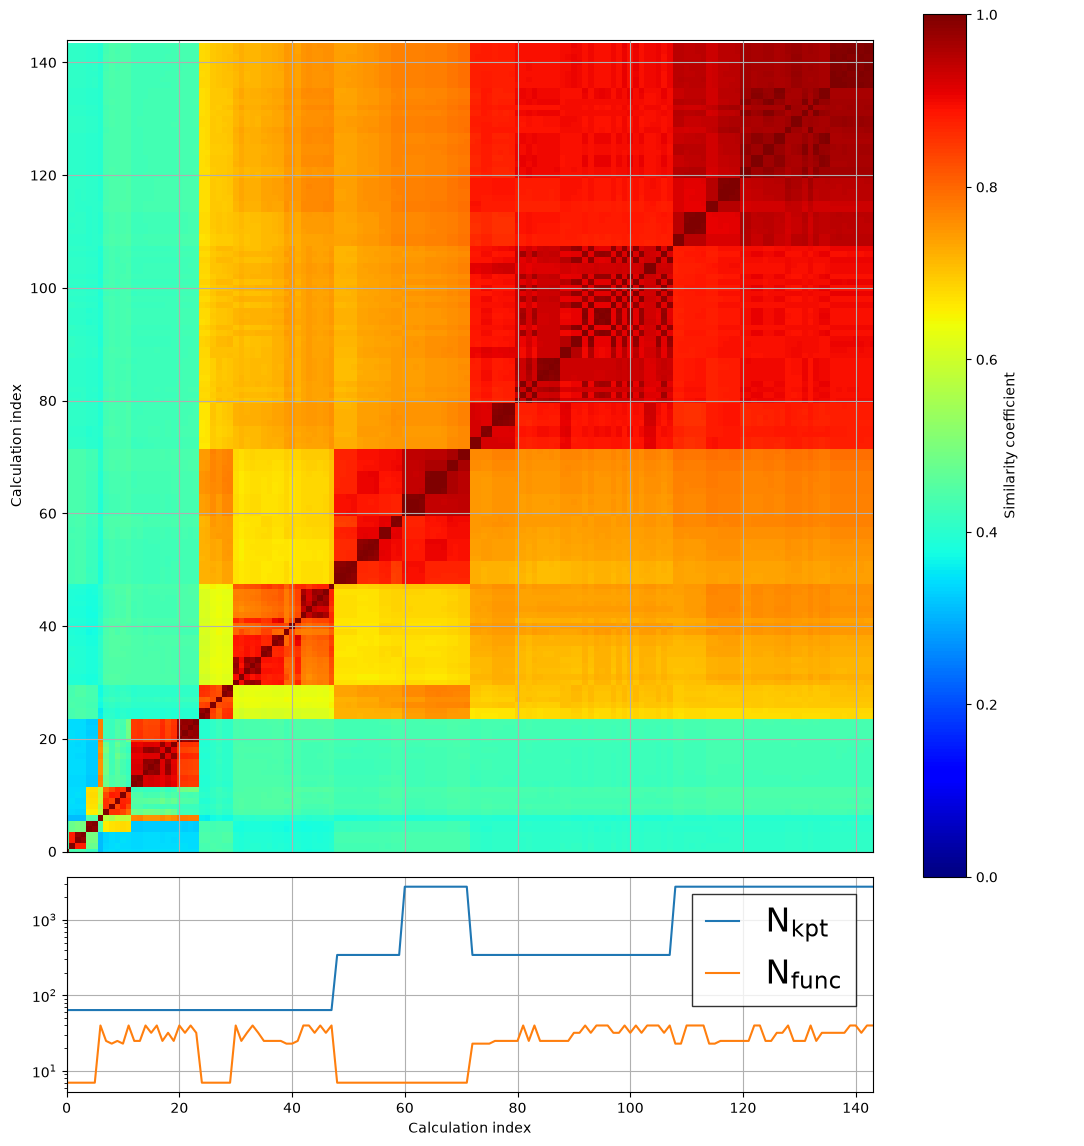

Calculation count complete: True
Heatmap generated: True
Preflight successful: True


In [25]:
# Define the AlGaO3 preflight heatmap filename inside the configured directory.
preflight_heatmap_path = heatmap_dir / "AlGaO3_DOS_similarity_heatmap.svg"

# Create the heatmap and the two numerical-setting curves beneath it.
similarity_kpoint_nfunc_plot(
    preflight_simat,
    preflight_kpoints,
    preflight_nfunc,
    filename=str(preflight_heatmap_path),
    cmap="jet",
)

# Check whether the heatmap file was successfully created.
heatmap_generated = preflight_heatmap_path.exists()

# The preflight succeeds only when retrieval is complete and the heatmap exists.
preflight_successful = calculation_count_complete and heatmap_generated

# Display only the relevant validation results.
print("Calculation count complete:", calculation_count_complete)
print("Heatmap generated:", heatmap_generated)
print("Preflight successful:", preflight_successful)